<a href="https://colab.research.google.com/github/Carlitos-A/Optimizacion_analisis_red_neuronal/blob/main/Evaluacion1_MLP_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EP1 Clasificación de Material Curricular con una Red Neuronal MLP

**Asignatura:** Deep Learning
**Evaluación:** EP1 – Implementación de una red neuronal MLP con TensorFlow/Keras
**Estudiantes:** *Carlos Camero y Carlos Muñoz*

---

## 1. Introducción

### 1.1 Descripción del problema

Se dispone de un dataset de **100.000 guías/documentos curriculares de matemáticas**, descritos por **22 características de contenido** (nivel escolar, duración estimada, número de páginas e ítems, proporciones de contenido por eje temático, densidad de símbolos, dificultad estimada, etc.). Cada documento pertenece a **una de 4 categorías curriculares** (clases 0, 1, 2 y 3), codificadas en la columna `categoria_curricular`.

### 1.2 Objetivo del modelo

Construir y evaluar una **red neuronal multicapa (MLP, Multi-Layer Perceptron)** implementada con **TensorFlow/Keras** que aprenda a clasificar automáticamente un documento curricular en su categoría correspondiente a partir de sus 22 características.

### 1.3 Tipo de clasificación

- **Clasificación supervisada multiclase (single-label):** cada ejemplo pertenece a exactamente una de las 4 clases.
- Las etiquetas son **enteras (0, 1, 2, 3)**, lo que influirá en la elección de la función de pérdida (se justificará en la Sección 5).
- La distribución de clases es: clase 0 = 30.219, clase 1 = 26.967, clase 2 = 23.065 y clase 3 = 19.749 ejemplos, es decir, un **desbalance Leve/Medio** que se tendrá en cuenta al interpretar las métricas.

### 1.4 Estructura de este notebook

1. Carga y exploración de datos. (Entre otros)
2. Preprocesamiento (separación X/y, split train/validación/test, escalado).
3. Construcción y entrenamiento del modelo MLP base.
4. Evaluación inicial del modelo base.
5. Próximos pasos (experimentos planificados).

**Nota metodológica:** siguiendo la rúbrica de la evaluación, **cada bloque de código está precedido por una celda Markdown que explica QUÉ se hace y POR QUÉ se hace**, de modo que todas las decisiones de diseño queden documentadas.

In [61]:
#--Librerías--
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
#----------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

#Fijación de semillas
SEED = 42
random.seed(SEED)          # semilla del módulo random de Python
np.random.seed(SEED)       # semilla de NumPy
tf.random.set_seed(SEED)   # semilla de TensorFlow (inicialización de pesos, etc.)

print("Versión de TensorFlow:", tf.__version__)



Versión de TensorFlow: 2.20.0


##Carga y exploración de datos

###Importación de librerías y fijación de semillas

**¿Qué se hace?** Se importan todas las librerías necesarias y se fijan las semillas aleatorias de `random`, `numpy` y `tensorflow`.

**¿Por qué?**

- **pandas / numpy:** manipulación del dataset y operaciones numéricas.
- **matplotlib / seaborn:** visualizaciones (distribución de clases, curvas de entrenamiento, matriz de confusión).
- **tensorflow (Keras):** construcción y entrenamiento de la red neuronal MLP. (Se instancia la versión para confirmar que existe instaldo en Colab)
- **sklearn:** utilidades de preprocesamiento (`train_test_split`, `StandardScaler`) y métricas de evaluación.
- **Semillas:** las redes neuronales involucran procesos aleatorios (inicialización de pesos, orden de los batches). Fijar las semillas hace que los resultados sean **deterministas**, condición necesaria para que los experimentos posteriores sean comparables entre sí considerando esta semilla.

In [62]:
# Carga del dataset


NOMBRE_ARCHIVO = '/content/sample_data/Dataset_Clasificacion_Curricular_100000_LIMPIO.csv'

df = pd.read_csv(NOMBRE_ARCHIVO)
print(f"Dataset cargado correctamente: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dataset cargado correctamente: 100,000 filas x 23 columnas


##Carga del dataset

**¿Qué se hace?** Se carga el archivo CSV en un DataFrame de pandas usando una ruta relativa simple

In [63]:
# Inspección inicial: dimensiones, tipos, nulos y duplicados

print("Dimensiones del dataset (filas, columnas):", df.shape)

print("\n --------------------- Primeras 5 filas: ---------------------\n")
display(df.head())

print("\n------------------ Información de columnas y tipos de datos: ---------------------\n")
df.info()

print("\n------------------------- Valores nulos por columna: ----------------------------\n")
print(df.isnull().sum())

print("\n-------------------------- Número de filas duplicadas: ---------------------------\n", df.duplicated().sum())

Dimensiones del dataset (filas, columnas): (100000, 23)

 --------------------- Primeras 5 filas: ---------------------



,nivel_escolar,duracion_estimada_min,numero_paginas,numero_items,porcentaje_visual,densidad_simbolos,prop_operaciones_aritmeticas,prop_fracciones_decimales,prop_variables_algebraicas,prop_ecuaciones,...,prop_coordenadas,prop_tablas_graficos,prop_estadistica_descriptiva,prop_probabilidad,prop_contexto_problemas,dificultad_estimada,ejemplos_resueltos,elementos_visuales,indice_interactividad,categoria_curricular
0,7,41,18,25,54.42,0.2335,0.4200,0.6755,0.0752,0.1390,...,0.1448,0.5649,0.6283,0.2008,0.4641,2,0,5,0.3486,0
1,6,62,19,28,31.81,0.5357,0.5404,0.5512,0.4638,0.6847,...,0.3178,0.2299,0.2365,0.1484,0.7197,3,4,5,0.3725,1
2,12,49,12,27,46.90,0.3354,0.1622,0.3779,0.2806,0.4657,...,0.3686,0.0967,0.1067,0.0050,0.3689,3,2,6,0.2390,2
3,9,47,19,28,60.19,0.3546,0.1766,0.5883,0.1324,0.3927,...,0.1421,0.3458,0.4779,0.3623,0.4923,3,4,6,0.2807,3
4,8,32,14,12,72.43,0.2983,0.2337,0.0566,0.1475,0.3370,...,0.8311,0.4640,0.3562,0.2224,0.2690,2,3,6,0.0577,2



------------------ Información de columnas y tipos de datos: ---------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   nivel_escolar                 100000 non-null  int64  
 1   duracion_estimada_min         100000 non-null  int64  
 2   numero_paginas                100000 non-null  int64  
 3   numero_items                  100000 non-null  int64  
 4   porcentaje_visual             100000 non-null  float64
 5   densidad_simbolos             100000 non-null  float64
 6   prop_operaciones_aritmeticas  100000 non-null  float64
 7   prop_fracciones_decimales     100000 non-null  float64
 8   prop_variables_algebraicas    100000 non-null  float64
 9   prop_ecuaciones               100000 non-null  float64
 10  prop_patrones_funciones       100000 non-null  float64
 11  prop_figuras_geometr

##Inspección inicial del dataset

**¿Qué se hace?** Se revisan las dimensiones del dataset (`shape`), las primeras filas (`head`), los tipos de datos (`info`), la cantidad de **valores nulos** y de **filas duplicadas**.

**¿Por qué?** Antes de entrenar cualquier modelo es obligatorio verificar la **calidad e integridad de los datos**: valores nulos o duplicados pueden sesgar el entrenamiento o inflar artificialmente las métricas. Confirmar los tipos de datos asegura que todas las columnas sean numéricas y aptas para alimentar una red neuronal.

Distribución de clases del target (categoria_curricular): 

-------------------------------------------------------------
categoria_curricular
0    30219
1    26967
2    23065
3    19749
Name: count, dtype: int64

Proporción por clase (%): 

-------------------------------------------------------------
categoria_curricular
0    30.22
1    26.97
2    23.06
3    19.75
Name: count, dtype: float64
-------------------------------------------------------------


/tmp/ipykernel_572/3300685372.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='categoria_curricular', palette='viridis')


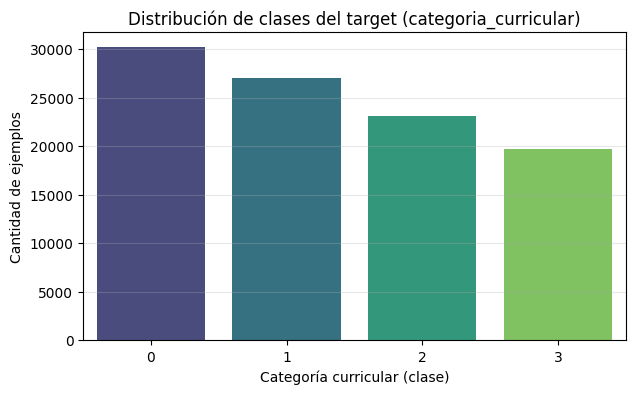

In [64]:
# Distribución de clases del target
conteo_clases = df['categoria_curricular'].value_counts().sort_index()

print("Distribución de clases del target (categoria_curricular): \n")
print("-------------------------------------------------------------")
print(conteo_clases)
print("\nProporción por clase (%): \n")
print("-------------------------------------------------------------")
print((conteo_clases / len(df) * 100).round(2))
print("-------------------------------------------------------------")

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='categoria_curricular', palette='viridis')
plt.title('Distribución de clases del target (categoria_curricular)')
plt.xlabel('Categoría curricular (clase)')
plt.ylabel('Cantidad de ejemplos')
plt.grid(axis='y', alpha=0.3)
plt.show()

##Análisis de los hallazgos exploratorios

A partir de la exploración anterior (y del análisis exploratorio previo del dataset) se concluye:

- **Tamaño:** 100.000 filas × 23 columnas (22 features + 1 target). Es un volumen de datos suficiente para entrenar un MLP sin necesidad de técnicas de aumentación.

- **Calidad:** **no hay valores nulos ni filas duplicadas**, por lo que no se requiere imputación ni limpieza adicional.

- **Target:** clasificación multiclase con 4 clases y **desbalance leve** (clase mayoritaria ≈ 30,2% y minoritaria ≈ 19,7% del total). Al ser leve, **no se aplicarán técnicas de rebalanceo**, pero se evaluará con métricas por clase (precision, recall, F1) además del accuracy.

- **Escalas heterogéneas:** algunas features están en rango 0–1 (las 12 columnas `prop_*`, `densidad_simbolos`, `indice_interactividad`), mientras otras llegan hasta 95 (`porcentaje_visual`), 83 (`duracion_estimada_min`) o 43 (`numero_items`). Esto **justifica el escalado** de las variables.

- **Correlaciones con el target:** las más altas son `prop_operaciones_aritmeticas` (−0,53), `prop_fracciones_decimales` (−0,50), `prop_tablas_graficos` (+0,46), `prop_probabilidad` (+0,44) y `prop_estadistica_descriptiva` (+0,44). Esto sugiere que la composición temática del documento es muy informativa para la clasificación.

- **Multicolinealidad:** no existen pares de features con correlación superior a 0,8, por lo que **no es necesario eliminar variables redundantes**; las 22 features se conservan como entrada del modelo.

Es un muy buen dataset para empezar el entrenamiento.

In [65]:
# Separación de features (X) y target (y)

TARGET = 'categoria_curricular'

X = df.drop(columns=[TARGET])  # 22 features de entrada
y = df[TARGET]                 # etiquetas enteras 0-3

print("---Features (X):---\n", X.shape)
print("---Target   (y):---\n", y.shape)
print("\n---Columnas utilizadas como features:--- \n")
print(list(X.columns))

---Features (X):---
 (100000, 22)
---Target   (y):---
 (100000,)

---Columnas utilizadas como features:--- 

['nivel_escolar', 'duracion_estimada_min', 'numero_paginas', 'numero_items', 'porcentaje_visual', 'densidad_simbolos', 'prop_operaciones_aritmeticas', 'prop_fracciones_decimales', 'prop_variables_algebraicas', 'prop_ecuaciones', 'prop_patrones_funciones', 'prop_figuras_geometricas', 'prop_medicion_angulos', 'prop_coordenadas', 'prop_tablas_graficos', 'prop_estadistica_descriptiva', 'prop_probabilidad', 'prop_contexto_problemas', 'dificultad_estimada', 'ejemplos_resueltos', 'elementos_visuales', 'indice_interactividad']


## Preprocesamiento
###Separación de features (X) y target (y)

**¿Qué se hace?** Se separa la columna target `categoria_curricular` (vector `y`) del resto de las columnas (matriz de features `X`).

**¿Por qué?** Los algoritmos de aprendizaje supervisado requieren por separado las **variables de entrada** y la **variable a predecir**. Además, separarlas explícitamente evita errores típicos como incluir accidentalmente el target como feature (lo que produciría una fuga de información y métricas artificialmente perfectas).

In [66]:
# Separación del 15% final como conjunto de prueba (test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# Dividir el 85% restante en train (70%) y validación (15%)
# 0.15/0.85 ≈ 0.1765 del conjunto temporal equivale al 15% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15 / 0.85,
    stratify=y_temp,
    random_state=42
)

# Verificación de tamaños y proporciones
for nombre, conjunto in [('-Train', y_train), ('-Validación', y_val), ('-Test', y_test)]:
    print(f"{nombre}: {len(conjunto):,} \n -Ejemplos ({len(conjunto) / len(y) * 100:.1f}%)")

print("\n---Proporción de clases por conjunto (debe ser similar, gracias a stratify):---")
resultados = {}
for nombre, conjunto in [
    ('-Train', y_train),
    ('-Validación', y_val),
    ('-Test', y_test)]:
    props = (
        conjunto.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)

    resultados[nombre] = props

tabla = pd.DataFrame(resultados).T

print("Proporción de clases por conjunto (%):")
display(tabla)

-Train: 69,999 
 -Ejemplos (70.0%)
-Validación: 15,001 
 -Ejemplos (15.0%)
-Test: 15,000 
 -Ejemplos (15.0%)

---Proporción de clases por conjunto (debe ser similar, gracias a stratify):---
Proporción de clases por conjunto (%):


categoria_curricular,0,1,2,3
-Train,30.22,26.97,23.06,19.75
-Validación,30.22,26.96,23.07,19.75
-Test,30.22,26.97,23.07,19.75


##División train / validación / test (70 / 15 / 15)

**¿Qué se hace?** Se divide el dataset en tres conjuntos: **70% entrenamiento, 15% validación y 15% prueba**, en dos pasos:

1. Primero se separa el **15% final como test** (queda un 85% temporal).
2. Luego ese 85% se divide en **train (70% del total)** y **validación (15% del total)**, usando `test_size = 0.15/0.85 ≈ 0.1765` sobre el conjunto temporal.

Ambos pasos usan `stratify=y` y `random_state=42`.

**¿Por qué?**

- **Tres conjuntos y no dos:** el conjunto de **validación** se usa para monitorear el entrenamiento y ajustar hiperparámetros, mientras que el de **prueba (test)** se reserva para la **evaluación final**, sin haber sido visto en ninguna decisión. Así la evaluación es una estimación honesta del desempeño en datos nuevos.
- **`stratify=y`:** garantiza que la proporción de las 4 clases se mantenga en los tres conjuntos, importante dado el desbalance leve del target.
- **`random_state=42`:** hace la división **reproducible**; cualquier ejecución del notebook genera exactamente los mismos conjuntos.

In [67]:
# Escalado: StandardScaler ajustado SOLO con train. Esto para lograr que las columnas con escalas diferentes sean más estandar.
scaler = StandardScaler()

# IMPORTANTE: el scaler se ajusta (fit) SOLO con el conjunto de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# El StandardScaler aprende cómo son los datos usando solamente X_train y después transforma X_train usando lo que aprendió.

# Validación y test solo se TRANSFORMAN con los parámetros aprendidos de train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


print("Escalado completado. Media y desviación estándar aprendidas de train:")
print("  Media (primeras 5 features):", np.round(scaler.mean_[:5], 3))
print("  Escala (primeras 5 features):", np.round(scaler.scale_[:5], 3))

Escalado completado. Media y desviación estándar aprendidas de train:
  Media (primeras 5 features): [ 8.493 37.08  13.205 19.664 53.62 ]
  Escala (primeras 5 features): [ 2.293 10.923  4.914  5.954 15.45 ]


###Escalado de features con StandardScaler

**¿Qué se hace?** Se estandarizan las 22 features con `StandardScaler` (media 0, desviación estándar 1). El scaler se **ajusta (`fit`) SOLO con el conjunto de entrenamiento** y luego se **aplica (`transform`)** a validación y test.

**¿Por qué?**

- **Escalas heterogéneas:** como se vio en la exploración, hay features en rango 0–1 junto a otras que llegan a 95. Las redes neuronales entrenan por descenso de gradiente, y cuando las variables tienen escalas muy distintas la optimización se vuelve lenta e inestable (los gradientes quedan dominados por las variables de mayor magnitud). Estandarizar pone todas las features en pie de igualdad y **acelera y estabiliza la convergencia**.
- **Ajustar solo con train (evitar data leakage):** si el scaler se ajustara con todo el dataset, la media y desviación de los conjuntos de validación y test "filtrarían" información hacia el entrenamiento. Eso es **fuga de datos (data leakage)** y produce métricas optimistas que no se sostienen en producción. Por eso: `fit` solo en train, `transform` en los tres.

In [68]:
# Verificación de shapes y del efecto del escalado
print("Shapes finales:")
print(f"  X_train: {X_train_scaled.shape} | y_train: {y_train.shape}")
print(f"  X_val:   {X_val_scaled.shape} | y_val:   {y_val.shape}")
print(f"  X_test:  {X_test_scaled.shape} | y_test:  {y_test.shape}")

print("\nMedia por feature en train escalado (debe ser ≈ 0):")
print(np.round(X_train_scaled.mean(axis=0), 2))

print("\nDesviación estándar por feature en train escalado (debe ser ≈ 1):")
print(np.round(X_train_scaled.std(axis=0), 2))

Shapes finales:
  X_train: (69999, 22) | y_train: (69999,)
  X_val:   (15001, 22) | y_val:   (15001,)
  X_test:  (15000, 22) | y_test:  (15000,)

Media por feature en train escalado (debe ser ≈ 0):
[-0.  0. -0.  0. -0. -0.  0.  0.  0.  0. -0. -0.  0. -0. -0. -0. -0. -0.
 -0.  0.  0.  0.]

Desviación estándar por feature en train escalado (debe ser ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


###Verificación de las dimensiones finales

**¿Qué se hace?** Se imprimen las dimensiones (`shape`) de todos los conjuntos y se comprueba que, tras el escalado, las features de train tengan media ≈ 0, todos iguales en un estandar de escala clave y desviación estándar ≈ 1. Esto cumple como una especie de control de calidad después del escalado con StandardScale

**¿Por qué?** Verificar las dimensiones antes de modelar permite detectar de inmediato errores en el split o en el escalado (por ejemplo, pérdida de columnas o de filas), y confirmar que la estandarización se aplicó correctamente. La dimensión de entrada de `X_train` (22) definirá la capa de entrada de la red.

In [70]:
# Definición de la arquitectura del MLP base
def crear_modelo_base(n_features, n_clases):
    """Construye el MLP base: Input(22) -> Dense(64, relu) -> Dense(32, relu) -> Dense(4, softmax)."""
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),               # 22 features de entrada
        tf.keras.layers.Dense(64, activation='relu', name='capa_oculta_1'),
        tf.keras.layers.Dense(32, activation='relu', name='capa_oculta_2'),
        tf.keras.layers.Dense(n_clases, activation='softmax', name='capa_salida')
    ], name='MLP_base')
    return modelo

n_features = X_train_scaled.shape[1]  # 22 features
n_clases = y_train.nunique()          # 4 clases

modelo_base = crear_modelo_base(n_features, n_clases)

##Modelo MLP base con Keras

###Arquitectura de la red

**¿Qué se hace?** Se define una red neuronal **secuencial** con la siguiente arquitectura:

| Capa | Neuronas | Activación |
|------|------|----------|
| Entrada | 22 | — | Una neurona por feature |
| Oculta 1 | 64 | ReLU | Extracción de patrones de alto nivel |
| Oculta 2 | 32 | ReLU | Refinamiento de la representación |
| Salida | 4 | Softmax | Una neurona por clase |

**¿Por qué esta arquitectura?**

- **MLP (capas densas):** las features son **tabulares** (no imágenes ni secuencias), por lo que un perceptrón multicapa totalmente conectado es el modelo apropiado; no se justifican capas convolucionales ni recurrentes.
- **Dos capas ocultas (64 → 32):** es una arquitectura **base razonable y parsimoniosa** para 22 features y 100.000 ejemplos: suficiente capacidad para aprender relaciones no lineales, pero pequeña para entrenar rápido y servir de **línea base** contra la cual comparar los experimentos posteriores. La reducción progresiva (64 → 32 → 4) obliga a la red a comprimir la información en representaciones cada vez más abstractas.
- **ReLU en las capas ocultas:** es la activación estándar en redes profundas por su buen comportamiento y su bajo costo computacional.
- **4 neuronas de salida:** una por cada categoría curricular.

In [72]:
# Compilación del modelo base
modelo_base.compile(
    optimizer=tf.keras.optimizers.Adam(),   # learning_rate por defecto = 0.001
    loss='sparse_categorical_crossentropy', # etiquetas enteras 0-3 (sin one-hot)
    metrics=['accuracy']
)

modelo_base.summary()

Model: "MLP_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,684 (14.39 KB)

 Trainable params: 3,684 (14.39 KB)

 Non-trainable params: 0 (0.00 B)

###Compilación del modelo

**¿Qué se hace?** Se compila el modelo con optimizador **Adam** (learning rate por defecto = 0,001), función de pérdida **`sparse_categorical_crossentropy`** y métrica **`accuracy`**.

**¿Por qué?**

- **Softmax en la capa de salida:** convierte los 4 valores de salida (logits) en una **distribución de probabilidad** sobre las clases (valores entre 0 y 1 que suman 1). Es la activación estándar para clasificación **multiclase single-label**, porque modela exactamente la pregunta "¿a cuál de las 4 categorías pertenece este documento?".
- **`sparse_categorical_crossentropy`:** es la entropía cruzada categórica para el caso en que las etiquetas son **enteros (0, 1, 2, 3)** en lugar de vectores one-hot. Es la pérdida correcta para multiclase porque mide la discrepancia entre la distribución predicha por softmax y la clase real; la variante *sparse* evita tener que convertir `y` a one-hot, ahorrando memoria y código. (La alternativa `categorical_crossentropy` requeriría `to_categorical(y)`.)
- **Adam:** optimizador adaptativo que ajusta la tasa de aprendizaje de cada parámetro combinando momentum y RMSProp. Converge rápido y de forma robusta con sus valores por defecto, por lo que es la elección estándar como **punto de partida**; en la Sección 6 se experimentará con otras tasas de aprendizaje.
- **Métrica `accuracy`:** proporción de aciertos; es intuitiva y sirve para monitorear el entrenamiento, aunque la evaluación final (Sección 5) la complementará con precision, recall y F1.

In [73]:
# Entrenamiento del modelo base

EPOCHS = 50
BATCH_SIZE = 32

historia_base = modelo_base.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8988 - loss: 0.2782 - val_accuracy: 0.9131 - val_loss: 0.2380
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9103 - loss: 0.2417 - val_accuracy: 0.9138 - val_loss: 0.2357
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9111 - loss: 0.2382 - val_accuracy: 0.9147 - val_loss: 0.2350
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9116 - loss: 0.2361 - val_accuracy: 0.9144 - val_loss: 0.2344
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9125 - loss: 0.2345 - val_accuracy: 0.9145 - val_loss: 0.2342
Epoch 6/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9125 - loss: 0.2334 - val_accuracy: 0.9146 - val_loss: 0.2342
Epoch 7/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9130 - loss: 0.2324 - val_accuracy: 0.9145 - val_loss: 0.2339
Epoch 8/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9132 - loss: 0.23

###Entrenamiento del modelo base

**¿Qué se hace?** Se entrena el modelo durante **50 épocas** con **batch_size = 32**, usando el conjunto de validación como `validation_data`.

**¿Por qué?**

- **`epochs = 50`:** un número moderado que permite observar la evolución completa del aprendizaje (y detectar visualmente sobreajuste en las curvas) sin que el tiempo de cómputo sea excesivo. Es la configuración **inicial** que luego se variará experimentalmente.
- **`batch_size = 32`:** valor estándar que equilibra estabilidad del gradiente (batches no demasiado pequeños) y frecuencia de actualización de los pesos (batches no demasiado grandes).
- **`validation_data = (X_val_scaled, y_val)`:** en cada época Keras evalúa la pérdida y el accuracy sobre el conjunto de validación **sin usarlo para actualizar pesos**. Esto permite monitorear la **capacidad de generalización** durante el entrenamiento y detectar sobreajuste.
- El historial devuelto por `fit()` se guarda en `historia_base` para graficar las curvas en la siguiente celda.

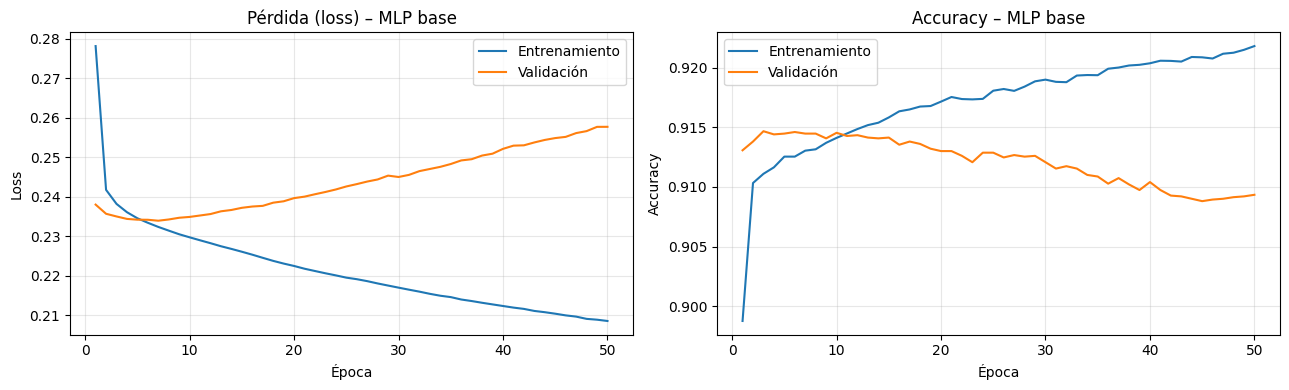

In [74]:
# Gráfico de curvas de pérdida y accuracy (train vs validación)
def graficar_curvas(historia, titulo='Modelo base'):
    """Grafica las curvas de pérdida y accuracy de entrenamiento y validación."""
    hist = historia.history
    epocas = range(1, len(hist['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Curva de pérdida
    axes[0].plot(epocas, hist['loss'], label='Entrenamiento')
    axes[0].plot(epocas, hist['val_loss'], label='Validación')
    axes[0].set_title(f'Pérdida (loss) – {titulo}')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Curva de accuracy
    axes[1].plot(epocas, hist['accuracy'], label='Entrenamiento')
    axes[1].plot(epocas, hist['val_accuracy'], label='Validación')
    axes[1].set_title(f'Accuracy – {titulo}')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

graficar_curvas(historia_base, titulo='MLP base')

### Curvas de aprendizaje (loss y accuracy)

**¿Qué se hace?** Se grafican las curvas de **pérdida** y **accuracy** de entrenamiento y validación a lo largo de las épocas.

**¿Por qué?** Las curvas de aprendizaje son la principal herramienta de **diagnóstico** del entrenamiento:

- Si la pérdida de **entrenamiento** sigue bajando mientras la de **validación** se estanca o sube, hay **sobreajuste (overfitting)**.
- Si ambas quedan altas y planas, hay **subajuste (underfitting)**.
- La brecha entre las curvas de train y validación indica cuánto generaliza el modelo.

Este diagnóstico orienta los experimentos de la Sección 6 (regularización, número de épocas, etc.).

In [75]:
# Predicciones y métricas sobre el conjunto de prueba
# Probabilidades softmax -> etiqueta de mayor probabilidad (argmax)

y_pred_prob = modelo_base.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=== Métricas del MLP base en el conjunto de PRUEBA ===")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall    (weighted): {recall:.4f}")
print(f"F1-score  (weighted): {f1:.4f}")

print("\nReporte de clasificación por clase:")
print(classification_report(y_test, y_pred))

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
=== Métricas del MLP base en el conjunto de PRUEBA ===
Accuracy            : 0.9045
Precision (weighted): 0.9045
Recall    (weighted): 0.9045
F1-score  (weighted): 0.9045

Reporte de clasificación por clase:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      4533
           1       0.91      0.91      0.91      4045
           2       0.90      0.90      0.90      3460
           3       0.92      0.90      0.91      2962

    accuracy                           0.90     15000
   macro avg       0.91      0.90      0.90     15000
weighted avg       0.90      0.90      0.90     15000



## Evaluación inicial del modelo base

### Métricas de clasificación sobre el conjunto de prueba

**¿Qué se hace?** Se generan las predicciones sobre el **conjunto de prueba** (que el modelo nunca vio durante el entrenamiento ni el ajuste) y se calculan **accuracy, precision, recall y F1-score** con `average='weighted'`, más el reporte por clase.

**¿Por qué?**

- **No basta con el accuracy:** con 4 clases y desbalance leve, el accuracy global puede ocultar un mal desempeño en la clase minoritaria. Precision, recall y F1 permiten ver el comportamiento **por clase**.
- **`average='weighted'`:** calcula cada métrica por clase y las promedia **ponderando por el soporte** (número de ejemplos reales de cada clase). Se elige esta variante porque refleja el desempeño global esperado sobre la distribución real de los datos. *(La alternativa `average='macro'` pondera todas las clases por igual; dado que el desbalance es leve, ambas deberían dar valores cercanos, y su comparación queda como ejercicio de análisis.)*
- **De probabilidades a etiquetas:** `predict()` devuelve las probabilidades softmax de las 4 clases; `argmax` selecciona la clase de mayor probabilidad, que es la decisión de clasificación natural en un problema single-label.


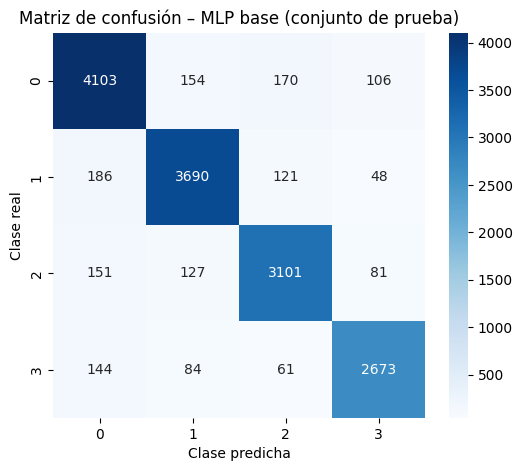

In [76]:
# Matriz de confusión (heatmap)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.title('Matriz de confusión – MLP base (conjunto de prueba)')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.show()

###Matriz de confusión

**¿Qué se hace?** Se calcula y visualiza la **matriz de confusión** de las predicciones sobre el conjunto de prueba, con un mapa de calor (`heatmap`).

**¿Por qué?** La matriz de confusión muestra **qué clases se confunden entre sí**: la diagonal principal contiene los aciertos y las celdas fuera de la diagonal, los errores. Esto permite identificar, por ejemplo, si las categorías curriculares adyacentes en dificultad o contenido se confunden más entre sí, información que ninguna métrica agregada entrega y que orienta mejoras posteriores (más capacidad, regularización, features adicionales, etc.).

In [77]:
# Cuadro resumen: línea base del modelo MLP base
resumen_base = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)'],
    'MLP base (test)': [round(accuracy, 4), round(precision, 4),
                        round(recall, 4), round(f1, 4)]
})

print("=== CUADRO RESUMEN – Evaluación inicial del MLP base ===")
print(resumen_base.to_string(index=False))

=== CUADRO RESUMEN – Evaluación inicial del MLP base ===
             Métrica  MLP base (test)
            Accuracy           0.9045
Precision (weighted)           0.9045
   Recall (weighted)           0.9045
 F1-score (weighted)           0.9045


###Cuadro resumen de la evaluación inicial

**¿Qué se hace?** Se consolidan las métricas del modelo base en un cuadro resumen que servirá como **línea base (baseline)** de referencia.

**¿Por qué?** Todos los experimentos de la Sección 6 (variación de hiperparámetros, regularización, etc.) se compararán contra estos valores para determinar de forma objetiva si cada cambio **mejora, empeora o no afecta** el desempeño del modelo.


##Conclusiones de la evaluación inicial
Desempeño global: (por completar)
Clases con más errores: (por completar)
Diagnóstico de las curvas de aprendizaje: (por completar)
Hipótesis para mejorar: (por completar)
